In [2]:
%load_ext autoreload
%autoreload 2

In [41]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
from shapely.geometry import Polygon, Point
import matplotlib.patches as mpatches
from matplotlib.cm import get_cmap

import geopandas as gpd

# from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

# Open data 

In [12]:
#Post process files 
df_labelled = gpd.read_file(DATA_PATH + 'results_proc/'+'post_processed_labelled_reports_impacts_all_geo_split_lowest.gpkg')
df_llm = gpd.read_file(DATA_PATH + 'results_proc/'+'post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct_geo.gpkg')

In [13]:
# Case study : 
appeal_cs = "MDRUG050" # "MDRSD034"
df_labelled_geo_cs = df_labelled.loc[df_labelled.appealCode==appeal_cs]
df_llm_geo_cs = df_llm.loc[df_llm.appealCode==appeal_cs]

In [16]:
# Plot of non-quantitative impact 

In [53]:
# Define groups
human_impacts = [
    "Affected People", "Injured People", "Displaced People", "Homeless People",
    "Missing People", "Human Deaths", "Human Health and Wellbeing",
    "Infected and Ill People", "Other Human Impacts"
]

infra_impacts = [
    "Road Infrastructure", "Other Transportation Infrastructure",
    "Water, Sanitation, and Hygiene Infrastructure", "Healthcare Infrastructure",
    "IT and Communication Infrastructure", "Residential Buildings",
    "Informal settlements", "Education Infrastructure",
    "Power and Energy Production Infrastructure", "Agriculture Infrastructure",
    "Other Infrastructure Impacts"
]

service_impacts = [
    "Crop Production and Forestry", "Affected Livestock and Animals",
    "Other Agricultural Impacts", "Recreation, Tourism, and Culture",
    "Other Economic and Livelihood Impacts", "Access to Healthcare",
    "Access to Water, Sanitation, and Hygiene", "Access to transport and Mobility",
    "Water Quality and Availability", "Access to Education",
    "Access to Power and Energy", "Access to Food", "Other Service Access Impacts"
]

# Color maps for groups
# human_colors = plt.cm.Reds_r(
#     np.linspace(0.3, 0.9, len(human_impacts))
# )
# infra_colors = plt.cm.Blues_r(
#     np.linspace(0.3, 0.9, len(infra_impacts))
# )
# service_colors = plt.cm.Greens_r(
#     np.linspace(0.3, 0.9, len(service_impacts))
# )

# human_colors = get_cmap("tab10").colors[:len(human_impacts)]
# infra_colors = get_cmap("tab20").colors[:len(infra_impacts)]
# service_colors = get_cmap("tab20").colors[-len(service_impacts):]

# # Merge into dict
# impact_color_map = {}
# impact_color_map.update(dict(zip(human_impacts, human_colors)))
# impact_color_map.update(dict(zip(infra_impacts, infra_colors)))
# impact_color_map.update(dict(zip(service_impacts, service_colors)))

# --- Custom palettes ---
human_palette = [
    "#FFD700", "#FFB14E", "#FA8775", "#D3336F", "#8B1E3F",
    "#E66101", "#FDB863", "#B2182B", "#EF8A62"
]

infra_palette = [
    "#1F77B4", "#2CA02C", "#17BECF", "#7F7FFF", "#005082",
    "#0E6BA8", "#66C2A5", "#3288BD", "#253494"
]

service_palette = [
    "#4DAF4A", "#A65628", "#FF7F00", "#984EA3", "#999999",
    "#66C2A5", "#E41A1C", "#F781BF", "#8DD3C7", "#B3DE69", "#FFD92F", "#BC80BD"
]

In [55]:
# Assign colors to impacts
def assign_custom_colors(subtypes, palette):
    return {sub: palette[i % len(palette)] for i, sub in enumerate(subtypes)}

impact_color_map = {}
impact_color_map.update(assign_custom_colors(human_impacts, human_palette))
impact_color_map.update(assign_custom_colors(infra_impacts, infra_palette))
impact_color_map.update(assign_custom_colors(service_impacts, service_palette))

In [56]:
# Add colors 
gdf = df_labelled_geo_cs.copy()
# Unique admin levels
admin_types = gdf["locationLowestAdmin"].unique()

# Assign colors
gdf["impactColor"] = gdf["impactSubtype"].map(impact_color_map)

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_32852\1963749265.py:84: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.5)


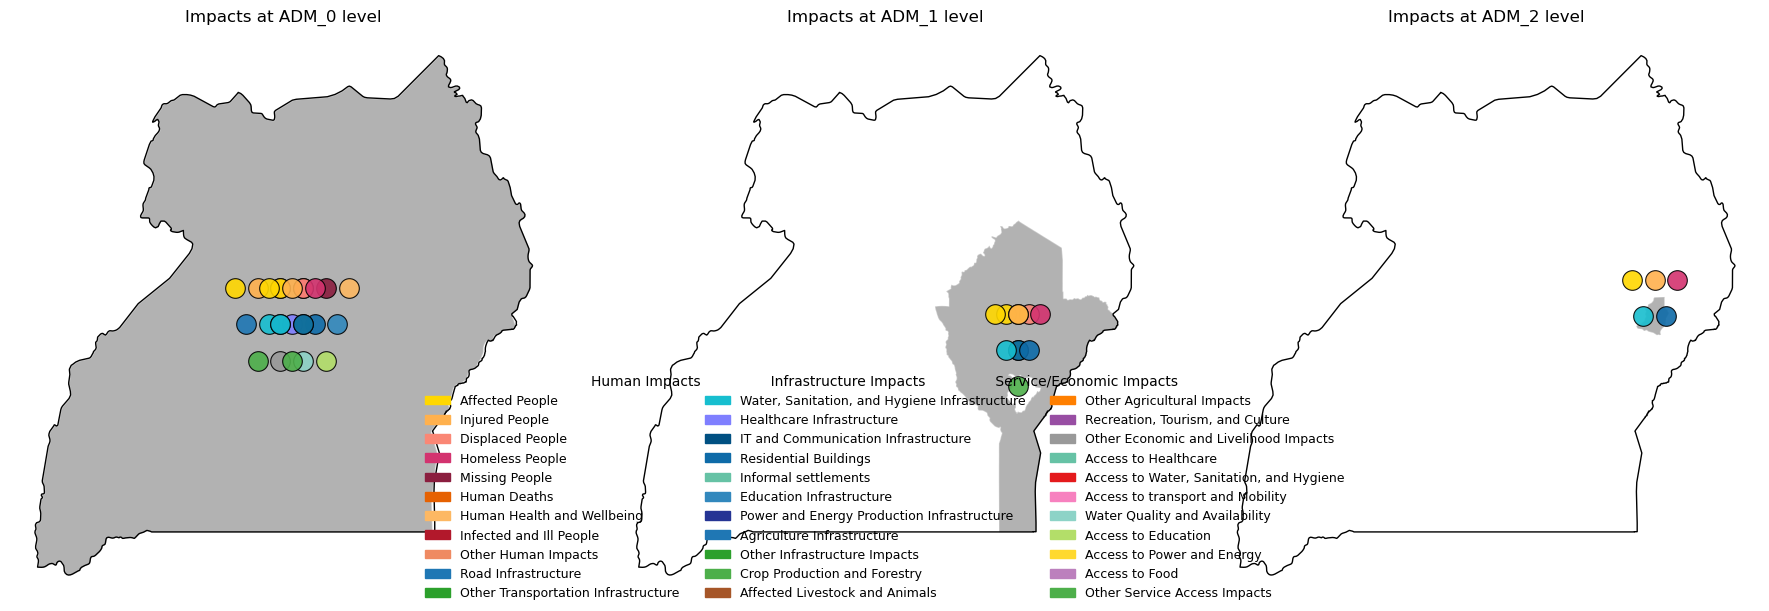

In [60]:
# Unique admin levels
admin_types = gdf["locationLowestAdmin"].unique()

# Setup subplots
fig, axes = plt.subplots(
    1, len(admin_types), figsize=(6*len(admin_types), 6), constrained_layout=True
)

if len(admin_types) == 1:
    axes = [axes]

for ax, admin in zip(axes, admin_types):
    subset = gdf[gdf["locationLowestAdmin"] == admin]

    if subset.empty:
        ax.set_title(f"Impacts at {admin} level")
        ax.axis("off")
        continue

    # Plot full country outline
    country_outline.boundary.plot(ax=ax, color="black", linewidth=1)

    # Shade impacted regions once
    subset.dissolve().plot(ax=ax, color="black", alpha=0.3, edgecolor="white")

    # Group by geometry
    for geom, group in subset.groupby(subset.geometry):
        centroid = geom.centroid

        # Keep unique impact types
        group_unique = group.drop_duplicates(subset="impactSubtype")

        # Organize by family
        families = {
            "Human": [s for s in group_unique["impactSubtype"] if s in human_impacts],
            "Infrastructure": [s for s in group_unique["impactSubtype"] if s in infra_impacts],
            "Service": [s for s in group_unique["impactSubtype"] if s in service_impacts],
        }

        # Plot each family in one row
        family_offsets = {"Human": 0.4, "Infrastructure": 0, "Service": -0.4}
        spacing = 0.25  # horizontal distance between dots

        for family, impacts in families.items():
            impacts_sorted = sorted(
                impacts, key=lambda x: list(impact_color_map.keys()).index(x)
            )
            for i, subtype in enumerate(impacts_sorted):
                color = impact_color_map[subtype]
                x = centroid.x + i * spacing - (len(impacts_sorted)-1) * spacing / 2
                y = centroid.y + family_offsets[family]
                ax.scatter(
                    x, y,
                    color=color,
                    s=200, edgecolor="black", linewidth=0.8, alpha=0.9
                )

    ax.set_title(f"Impacts at {admin} level")
    ax.axis("off")

# ===== Legend (3 columns, separated by family) =====
legend_elements = []

# Human
human_patches = [mpatches.Patch(color=impact_color_map[s], label=s) for s in human_impacts]
# Infrastructure
infra_patches = [mpatches.Patch(color=impact_color_map[s], label=s) for s in infra_impacts]
# Service
service_patches = [mpatches.Patch(color=impact_color_map[s], label=s) for s in service_impacts]

# Build combined legend
from matplotlib.legend import Legend

fig.legend(
    handles=human_patches + infra_patches + service_patches,
    labels=[p.get_label() for p in human_patches + infra_patches + service_patches],
    loc="lower center",
    ncol=3,
    fontsize=9,
    frameon=False,
    title="Human Impacts                Infrastructure Impacts                Service/Economic Impacts"
)

plt.subplots_adjust(bottom=0.5)
plt.show()


C:\Users\lhasbini\AppData\Local\Temp\ipykernel_32852\1696676205.py:105: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.5)


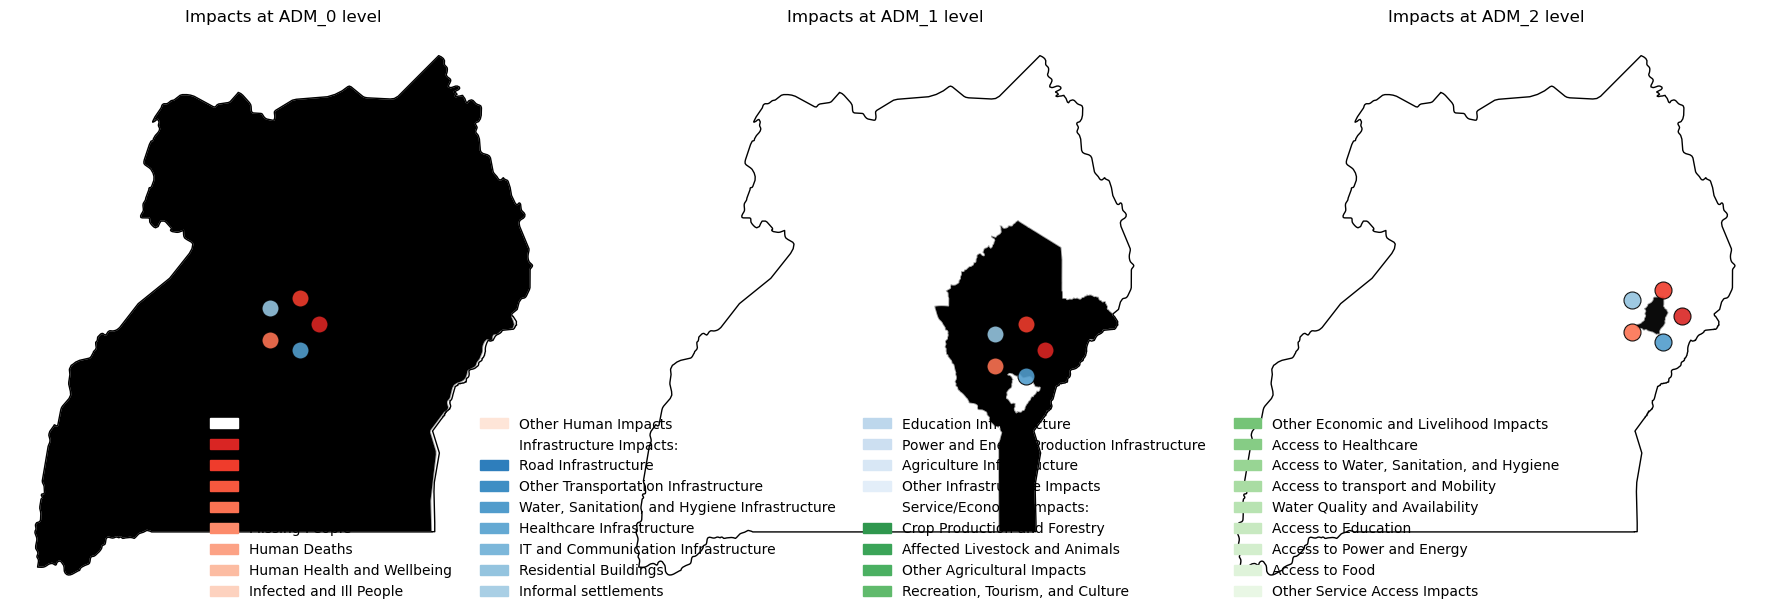

In [ ]:
# Unique admin levels
admin_types = gdf["locationLowestAdmin"].unique()

# Setup subplots
fig, axes = plt.subplots(
    1, len(admin_types), figsize=(6*len(admin_types), 6), constrained_layout=True
)

if len(admin_types) == 1:
    axes = [axes]

for ax, admin in zip(axes, admin_types):
    subset = gdf[gdf["locationLowestAdmin"] == admin]

    # Plot full country outline
    country_outline.boundary.plot(ax=ax, color="black", linewidth=1)

    # Shade impacted regions
    subset.plot(ax=ax, color="black", alpha=0.4, edgecolor="white")

    #Plot centroid to show the impact types 
    for geom, group in subset.groupby(subset.geometry):
        centroid = geom.centroid
        # Keep only one row per impactSubtype
        group_unique = group.drop_duplicates(subset="impactSubtype")
        n = len(group_unique)

        if n == 1:
            # Single dot at centroid
            row = group.iloc[0]
            ax.scatter(
                centroid.x, centroid.y,
                color=row["impactColor"],
                s=150, edgecolor="black", linewidth=0.5, alpha=0.9
            )
    else:
        # Parameters
        base_radius = 0.3   # bigger spread
        dots_per_ring = 8   # max per circle
        ring_spacing = 0.08 # spacing between concentric rings

        rings = int(np.ceil(n / dots_per_ring))

        idx = 0
        for r in range(rings):
            radius = base_radius + r * ring_spacing
            k = min(dots_per_ring, n - idx)
            angles = np.linspace(0, 2*np.pi, k, endpoint=False)

            for i in range(k):
                row = group_unique.iloc[idx]
                x = centroid.x + radius * np.cos(angles[i])
                y = centroid.y + radius * np.sin(angles[i])
                ax.scatter(
                    x, y,
                    color=row["impactColor"],
                    s=150, edgecolor="black", linewidth=0.8, alpha=0.9
                )
                idx += 1

    ax.set_title(f"Impacts at {admin} level")
    ax.axis("off")

# ===== Legend (Grouped) =====
# ===== Build full legend grouped by category =====
legend_elements = []

# Human impacts
legend_elements.append(mpatches.Patch(color='white', label='Human Impacts:'))  # group title
for subtype in human_impacts:
    color = impact_color_map[subtype]
    legend_elements.append(mpatches.Patch(color=color, label=subtype))

# Infrastructure impacts
legend_elements.append(mpatches.Patch(color='white', label='Infrastructure Impacts:'))
for subtype in infra_impacts:
    color = impact_color_map[subtype]
    legend_elements.append(mpatches.Patch(color=color, label=subtype))

# Service/Economic impacts
legend_elements.append(mpatches.Patch(color='white', label='Service/Economic Impacts:'))
for subtype in service_impacts:
    color = impact_color_map[subtype]
    legend_elements.append(mpatches.Patch(color=color, label=subtype))

# Add legend under all subplots
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,          # adjust for better layout
    fontsize=10,
    frameon=False
)

plt.subplots_adjust(bottom=0.5)
plt.show()


C:\Users\lhasbini\AppData\Local\Temp\ipykernel_32852\3431698969.py:83: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.25)


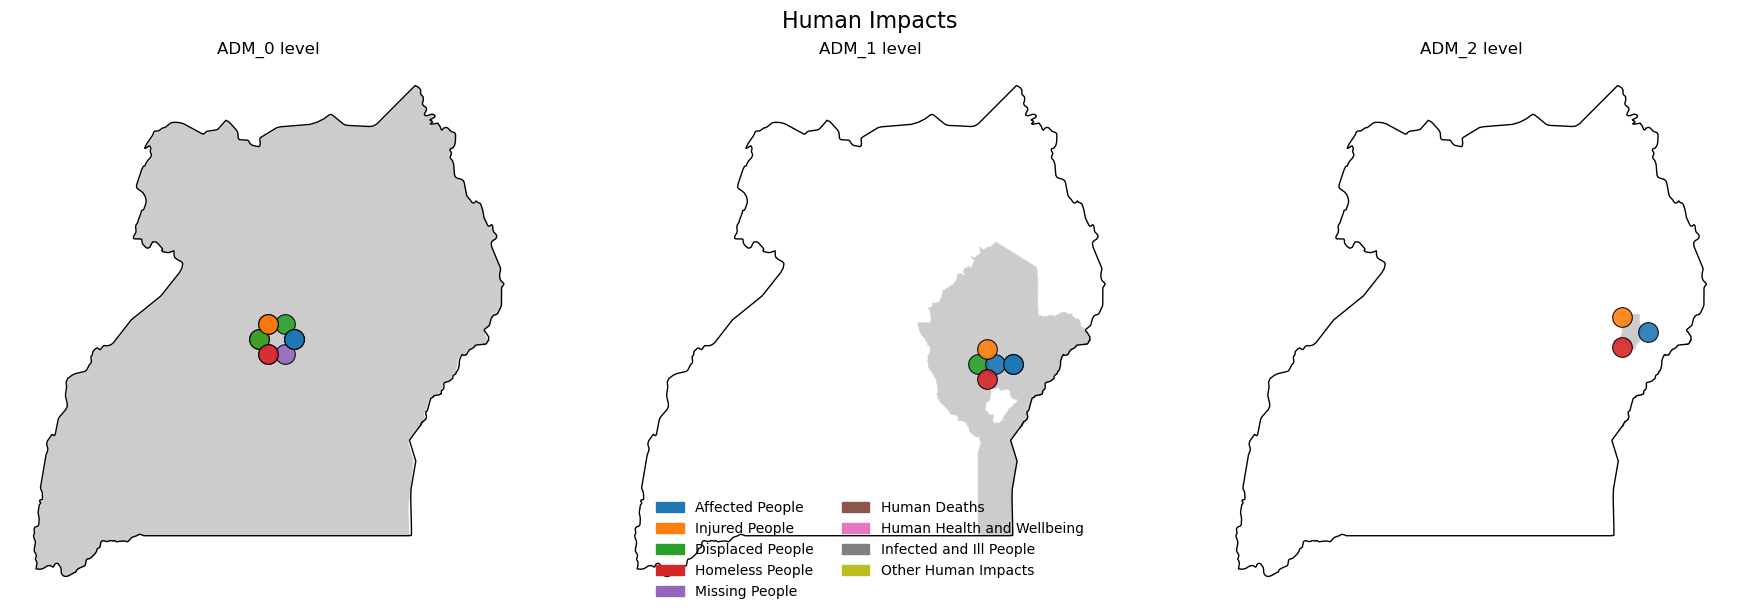

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_32852\3431698969.py:83: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.25)


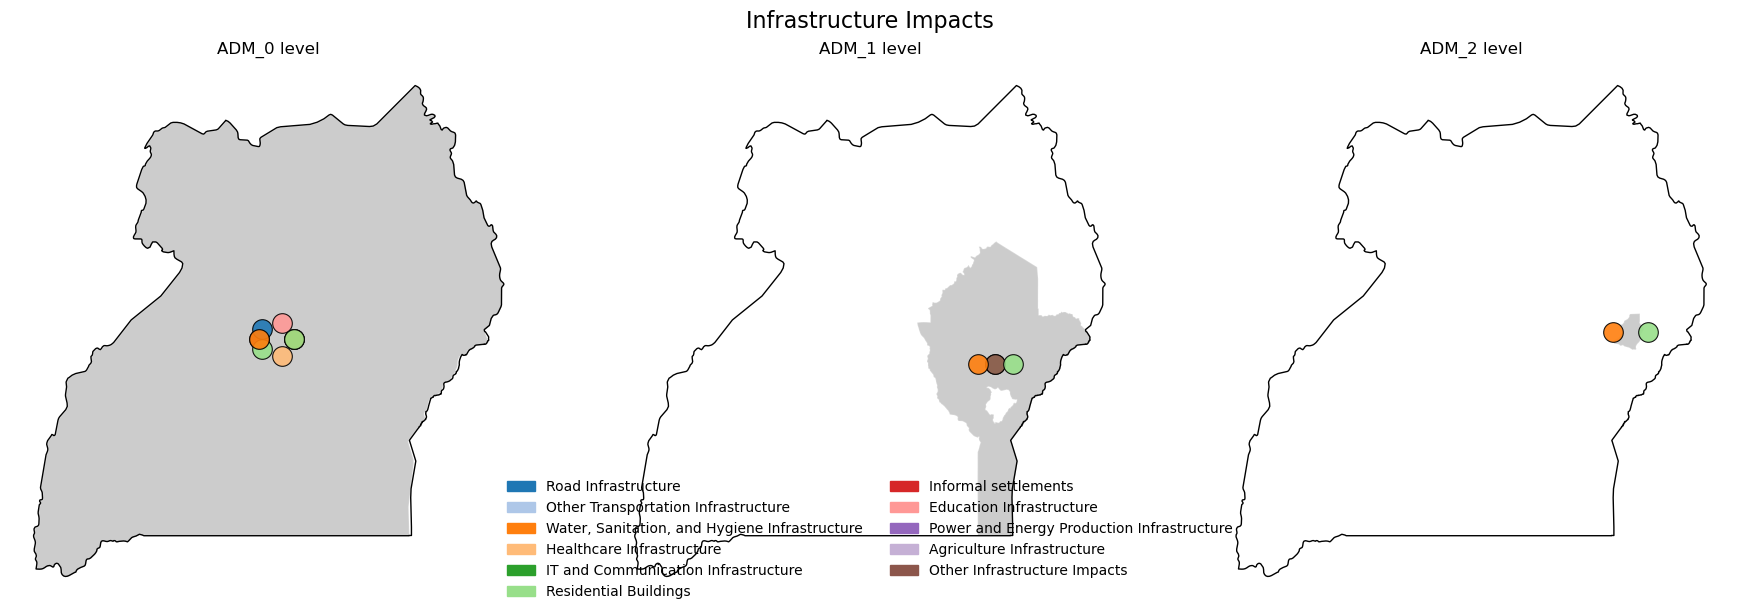

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_32852\3431698969.py:83: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.25)


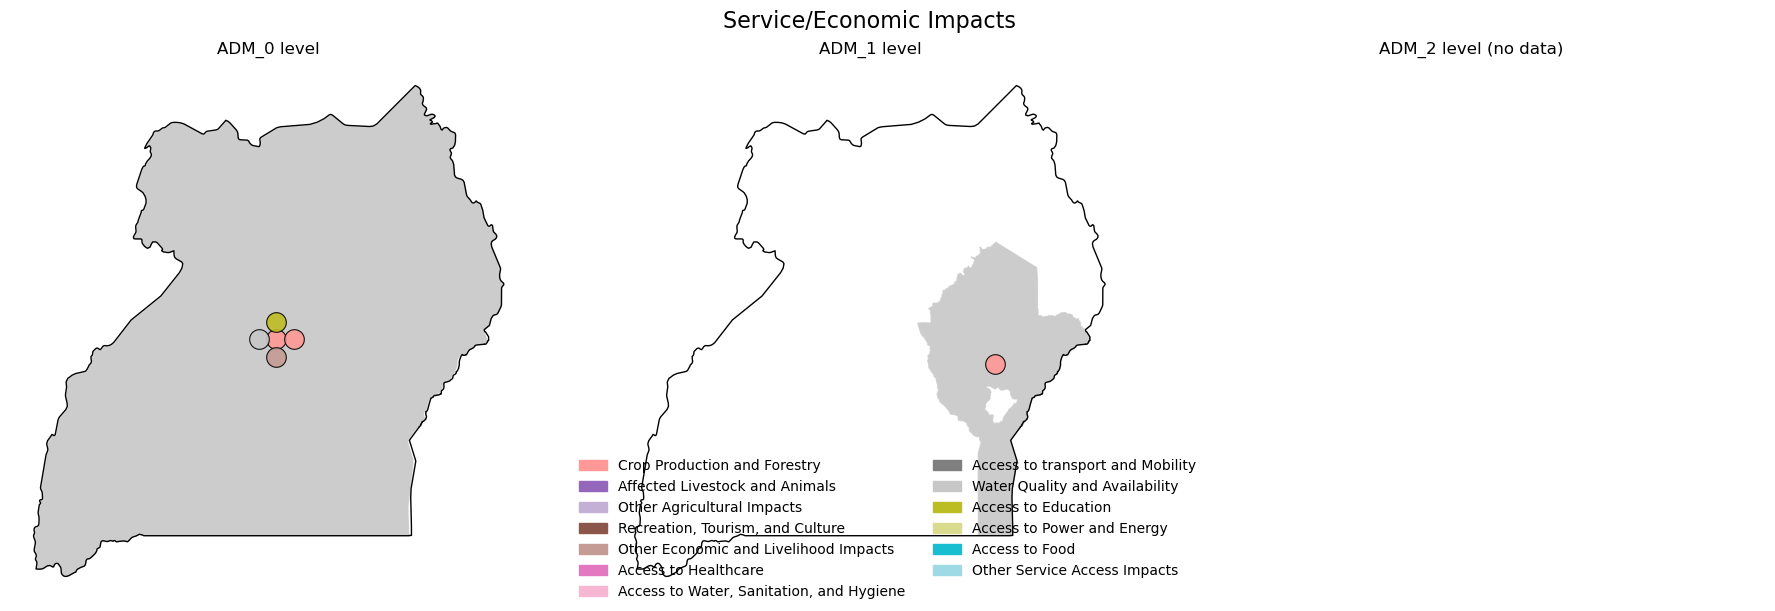

In [52]:
# Country boundary (background global picture)
country_outline = gdf.dissolve(by="country")

admin_types = gdf["locationLowestAdmin"].unique()
n_admin = len(admin_types)

families = {
    "Human": human_impacts,
    "Infrastructure": infra_impacts,
    "Service/Economic": service_impacts
}

for family_name, subtypes in families.items():
    fig, axes = plt.subplots(1, n_admin, figsize=(6*n_admin,6), constrained_layout=True)
    if n_admin == 1:
        axes = [axes]

    # Subset data for this family
    family_subset = gdf[gdf["impactSubtype"].isin(subtypes)]
    impacted_regions = family_subset.dissolve(by="locationLowestAdmin")

    for ax, admin in zip(axes, admin_types):
        subset = family_subset[family_subset["locationLowestAdmin"] == admin]

        if subset.empty:
            # Leave subplot empty
            ax.set_title(f"{admin} level (no data)")
            ax.axis("off")
            continue

        # Plot full country outline
        country_outline.boundary.plot(ax=ax, color="black", linewidth=1)

        # Shade impacted regions only once
        if admin in impacted_regions.index:
            impacted_regions.loc[[admin]].plot(
                ax=ax, color="black", alpha=0.2, edgecolor="white"
            )

        subset = family_subset[(family_subset["locationLowestAdmin"] == admin)]

        # Plot centroids (organized with concentric rings)
        for geom, group in subset.groupby(subset.geometry):
            centroid = geom.centroid
            group_unique = group.drop_duplicates(subset="impactSubtype")
            n = len(group_unique)

            if n == 1:
                row = group_unique.iloc[0]
                ax.scatter(
                    centroid.x, centroid.y,
                    color=row["impactColor"], s=200,
                    edgecolor="black", linewidth=0.8, alpha=0.9
                )
            else:
                # Concentric rings layout
                base_radius = 0.2
                dots_per_ring = 8
                ring_spacing = 0.1
                rings = int(np.ceil(n / dots_per_ring))
                idx = 0
                for r in range(rings):
                    radius = base_radius + r * ring_spacing
                    k = min(dots_per_ring, n - idx)
                    angles = np.linspace(0, 2*np.pi, k, endpoint=False)
                    for i in range(k):
                        row = group_unique.iloc[idx]
                        x = centroid.x + radius*np.cos(angles[i])
                        y = centroid.y + radius*np.sin(angles[i])
                        ax.scatter(
                            x, y,
                            color=row["impactColor"], s=200,
                            edgecolor="black", linewidth=0.8, alpha=0.9
                        )
                        idx += 1

        ax.set_title(f"{admin} level")
        ax.axis("off")

    # Legend for this family
    family_legend = [mpatches.Patch(color=impact_color_map[sub], label=sub) for sub in subtypes]
    fig.legend(handles=family_legend, loc="lower center", ncol=2, fontsize=10, frameon=False)
    plt.subplots_adjust(bottom=0.25)
    fig.suptitle(f"{family_name} Impacts", fontsize=16)
    plt.show()
